
## Academic Integrity and Learning Statement

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## Task G: Advanced EDA

- What is the total number of samples by country ? Countries with very small sample size should be dropped from this analysis
- Count the number of organic and non-organic products in each country. Is there a country with a higher percentage of organic products ?
- Compare the distributions of the macronutrients between organic and non-organic products in each country. (Check seaborn's violinplot)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data_clean.csv")

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3441: DtypeWarning: Columns (1,43,45) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [17]:
# Compute the total number of samples per country
df.groupby("country").size()

# we should remove france as it has only 63 entries
df = df[df["country"] != "FR"]

In [18]:
df.groupby(["country"])

country
CH     10599
DE      9643
IT      2445
US    200469
dtype: int64

In [45]:
# create a new column "organic" which says true or false depending on whether the product name contains bio or organic or ecological
df["organic"] = df.product_name_en.str.contains("organic|bio|eco", case=False, na=False)

print(df["organic"].sum(), "products are organic")

11874 products are organic


/tmp/ipykernel_136722/3274586520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["organic"] = df.product_name_en.str.contains("organic|bio|eco", case=False, na=False)


In [46]:
# now count the number of organic and non organic product in each country
print(df.groupby(["country", "organic"]).size())

country  organic
CH       False       10211
         True          388
DE       False        9617
         True           26
IT       False        2444
         True            1
US       False      189010
         True        11459
dtype: int64


In [47]:
# calculate the percentage of organic products per country
percent_organic = df.groupby("country")["organic"].sum() / df.groupby("country").size()

print(percent_organic)

country
CH    0.036607
DE    0.002696
IT    0.000409
US    0.057161
dtype: float64


#### Comments
It looks like around 3-6 % of products are organic in the US and in switzerland, and a lot less in germany and italy. This could however come from different ways of naming products. I also had a look if the ingredient list contains bio or organic, but this still necessarily wouldn't make a product organic as it can contain both organic and non organic ingredients (and would then be not organic). 

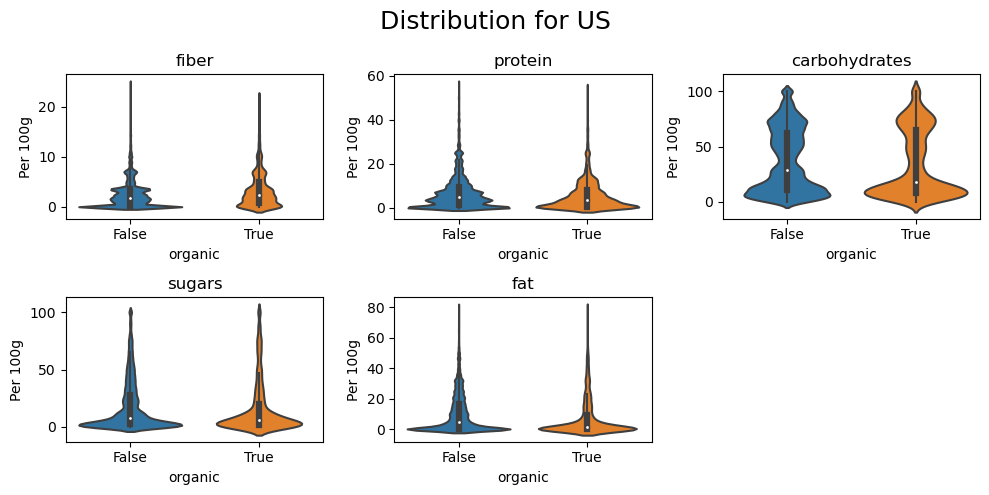

In [82]:
# Compare the distributions of the macronutrients between organic and non-organic products in each country.

# create four lists with the info for each country

df_US = df[df["country"] == "US"]
df_CH = df[df["country"] == "CH"]
df_IT = df[df["country"] == "IT"]
df_DE = df[df["country"] == "DE"]

macro_cols = ["fiber_per_hundred", "protein_per_hundred", "carbohydrates_per_hundred", "sugars_per_hundred", "fat_per_hundred"]

fig, axes = plt.subplots(2, 3, figsize=(10,5))
axes = axes.flatten()
for col, ax in zip(macro_cols, axes):
    sns.violinplot(data=df_US, y=col, x="organic", ax=ax)
    ax.set_title(col.replace('_per_hundred', ''))
    ax.set_ylabel("Per 100g")

# Hide the extra subplot
axes[-1].set_visible(False)
plt.suptitle("Distribution for US", fontsize=18)
plt.tight_layout()



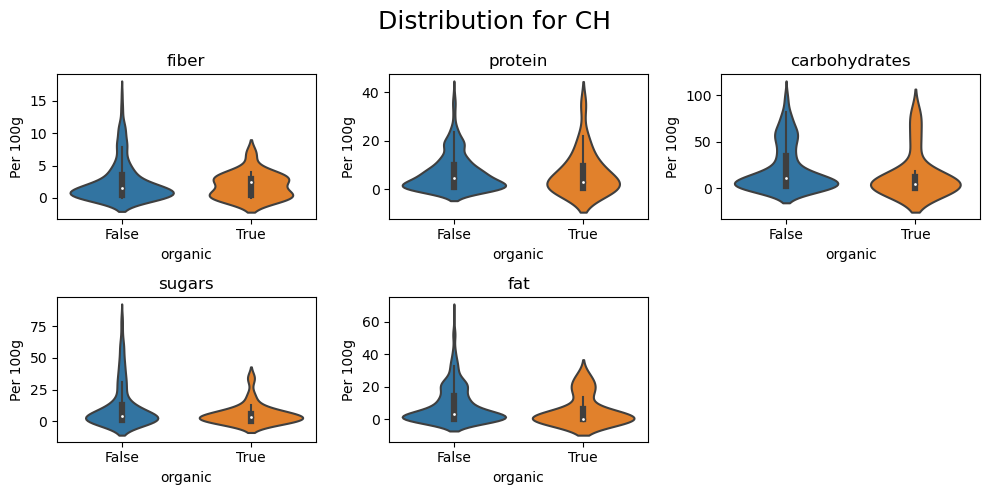

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(10,5))
axes = axes.flatten()
for col, ax in zip(macro_cols, axes):
    sns.violinplot(data=df_CH, y=col, x="organic", ax=ax)
    ax.set_title(col.replace('_per_hundred', ''))
    ax.set_ylabel("Per 100g")

# Hide the extra subplot
axes[-1].set_visible(False)
plt.suptitle("Distribution for CH", fontsize=18)
plt.tight_layout()

#### Comments

I only plotted the data for switzerland and the US as they are the two contries with the most entries. No clear difference jumps out from these graphs. It could now be interesting to do a statistical test on some of these variables to see if they are different between organic and non-organic foods.  

<AxesSubplot:xlabel='macronutrient', ylabel='value'>

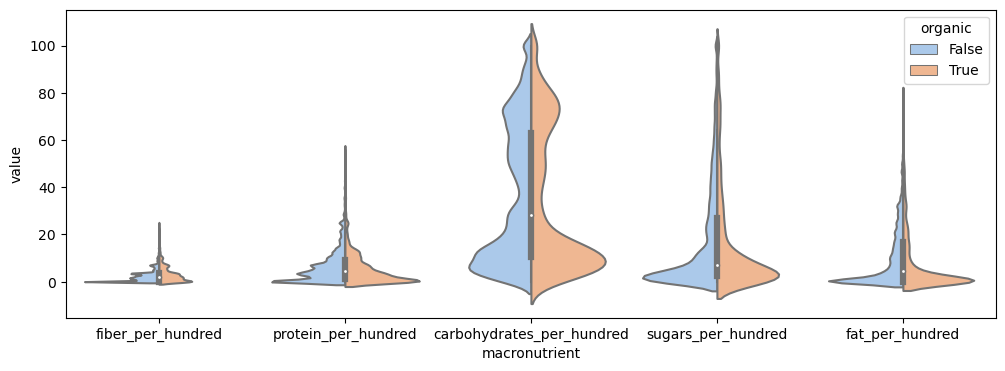

In [113]:
### trying out another way to plot the data. 
df_US_subset = df_US[macro_cols + ["organic"]]

# you need to have the data in a long format for seaborn violin plots, with one column containing organic vs non organic (for the hue)
# one column containing what you want on the x axis (here the different macronutrients), and one column with the value for all combinations
df_US_subset = df_US_subset.melt(id_vars="organic", value_vars=macro_cols, var_name="macronutrient")

plt.figure(figsize=(12,4))
sns.violinplot(data = df_US_subset, x="macronutrient", y="value", hue="organic", split=True, palette="pastel")